In [12]:
# CELLULE 1 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import joblib
import warnings
warnings.filterwarnings('ignore')

COLOR_BLUE  = "#163767"
COLOR_RED   = "#E53935"
COLOR_GREEN = "#43A047"

# Chargement
df = pd.read_csv('../data/predictive_maintenance_v3.csv')

# Colonnes inutiles à supprimer
cols_to_drop = ['timestamp', 'machine_id', 'rul_hours', 
                'failure_type', 'estimated_repair_cost']
df = df.drop(columns=cols_to_drop)

print(f"Shape après nettoyage : {df.shape}")
print(f"Colonnes restantes : {list(df.columns)}")

Shape après nettoyage : (24042, 10)
Colonnes restantes : ['machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'failure_within_24h']


In [13]:
# CELLULE 2 - Définition des features et split train/test
NUMERIC_FEATURES = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                    'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']
CATEGORICAL_FEATURES = ['machine_type', 'operating_mode']
TARGET = 'failure_within_24h'

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Split stratifié (conserve les proportions de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Proportion pannes train : {y_train.mean():.1%}")
print(f"Proportion pannes test  : {y_test.mean():.1%}")

Train : (19233, 9) | Test : (4809, 9)
Proportion pannes train : 14.8%
Proportion pannes test  : 14.8%


In [14]:
# CELLULE 3 - Pipeline de preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, NUMERIC_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES)
])

# Fit sur train uniquement, transform sur train et test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Noms des colonnes après preprocessing
cat_cols = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = NUMERIC_FEATURES + list(cat_cols)

print(f"X_train_processed shape : {X_train_processed.shape}")
print(f"X_test_processed shape  : {X_test_processed.shape}")
print(f"Features après encoding : {feature_names}")

X_train_processed shape : (19233, 14)
X_test_processed shape  : (4809, 14)
Features après encoding : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'machine_type_CNC', 'machine_type_Compressor', 'machine_type_Pump', 'machine_type_Robotic Arm', 'operating_mode_idle', 'operating_mode_normal', 'operating_mode_peak']


Preprocessor sauvegardé
Données preprocessées sauvegardées


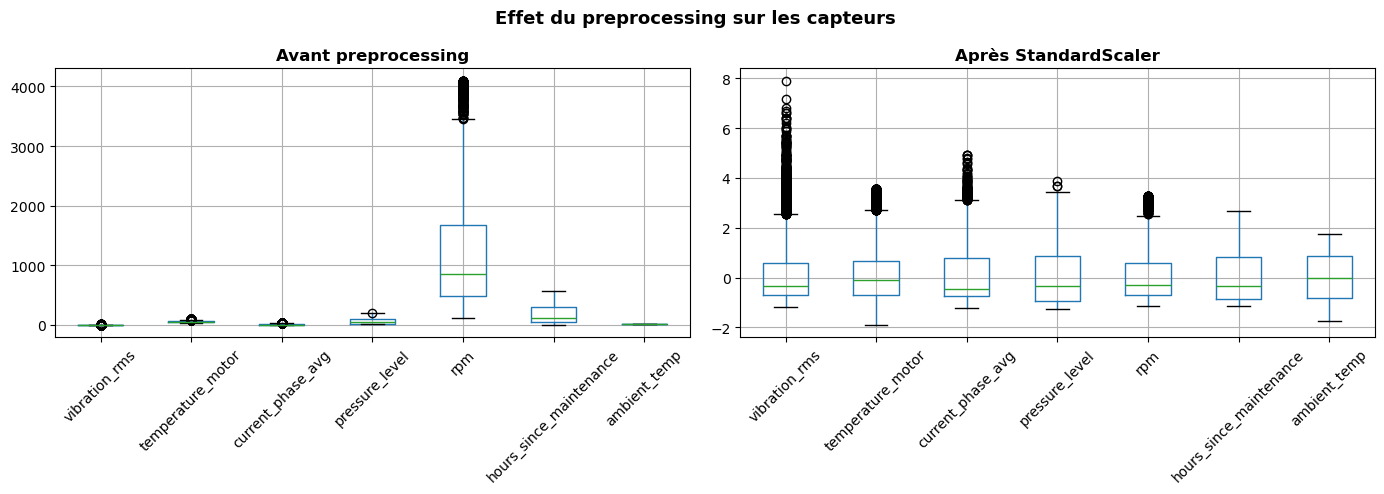

In [15]:
# CELLULE 4 - Sauvegarde du preprocessor et des données
import os
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Sauvegarde preprocessor
joblib.dump(preprocessor, '../models/preprocessor.joblib')
print("Preprocessor sauvegardé")

# Sauvegarde des splits
np.save('../data/processed/X_train.npy', X_train_processed)
np.save('../data/processed/X_test.npy', X_test_processed)
np.save('../data/processed/y_train.npy', y_train.values)
np.save('../data/processed/y_test.npy', y_test.values)
print("Données preprocessées sauvegardées")

# Vérification visuelle avant/après scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant
df[NUMERIC_FEATURES].boxplot(ax=axes[0])
axes[0].set_title('Avant preprocessing', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Après
pd.DataFrame(X_train_processed[:, :7], columns=NUMERIC_FEATURES).boxplot(ax=axes[1])
axes[1].set_title('Après StandardScaler', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Effet du preprocessing sur les capteurs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/preprocessing_before_after.png', dpi=150, bbox_inches='tight')
plt.show()